# ICePop tutorial

## 1. Extract metacells

In [ ]:
! icepop metacell \
    --h5ad ../data/TM_FACS/TM_FACS_cnt.h5ad \
    --outdir ../results/TM_FACS_mc-75 \
    --save_name TM_FACS \
    --device cpu # or 'cuda' (default) to speed up the run

2026-03-26 20:24:23,732 - icepop.metacell - INFO - Max expression value: 31922356.0
2026-03-26 20:24:23,732 - icepop.metacell - INFO - Totol number of cells: 110824, target metacell number: 1478
2026-03-26 20:24:23,732 - icepop.metacell - INFO - Running MetaQ
=======Loading and Preprocessing Data=======
Data of 1 omics in total
data/TM_FACS/TM_FACS_cnt.h5ad loaded with shape [110824, 2815]
Target metacell number: 1478
======= Training Start =======
[Epoch 20] RNA: Loss Rec=0.7936 Loss Rec Q=0.8123 | Codebook: Loss C=0.0034     in 0s (~0s, 548.1/s) (~3:15, 1.3/s) in 37s (~59:19, 0.1/s)8/300 [3%] in 2:20 (~1:25:28, 0.1in 3:12 (~1:32:09, 0.in 3:22 (~1:33:30, 0.(~1:31:17, 0.(~1:30:35, 0.14/300 [5%] in 4:27 (~1:33:44, 0.in 4:57 (~1:33:31, 0.16/300 [5%] in 5:15 (~1:32:43, 0. ▂▄▆ 16/300 [5%] in 5:28 (~1:36:43, 0.(~1:32:56, 0.▅▃▁ 18/300 [6%] in 5:52 (~1:36:11, 0.(~1:35:50, 0.
[Epoch 40] RNA: Loss Rec=0.7782 Loss Rec Q=0.8007 | Codebook: Loss C=0.0030     (~1:34:03, 0.(~1:34:52, 0.(~1:33:59, 0.

## 2. Get association, mixture and influence diagnoistics

In [1]:
! icepop association \
    --h5ad ../data/TM_FACS/TM_FACS_cnt.h5ad \
    --mc_assign ../results/TM_FACS_mc-75/mc_assign.csv \
    --magmaz ../data/magmaz/PASS_UC_deLange2017.genes.out \
    --spec_score ../results/TM_FACS_mc-75/mc_spec_score.npz \
    --sp mmusculus \
    --outdir ../results/TM_icepop_mc-75

2026-05-06 13:34:04,742 - icepop.association - INFO - Starting association analysis
2026-05-06 13:34:04,742 - icepop.association - INFO - Inputs: h5ad=../data/TM_FACS/TM_FACS_cnt.h5ad, mc_assign=../results/TM_FACS_mc-75/mc_assign.csv, magmaz=../data/magmaz/PASS_UC_deLange2017.genes.out
2026-05-06 13:34:04,742 - icepop.association - INFO - Params: ct_key=cell_type, sp=mmusculus, n_perm=2000, q_thres=0.1, n_jobs=20
2026-05-06 13:34:04,742 - icepop.association - INFO - Loading h5ad and metacell assignment
2026-05-06 13:34:09,050 - icepop.association - INFO - Loaded adata: n_cells=110824, n_genes=22499
2026-05-06 13:34:09,053 - icepop.association - INFO - Number of cell_type: 120
2026-05-06 13:34:09,131 - icepop.association - INFO - Number of metacells 1432
2026-05-06 13:34:09,173 - icepop.association - INFO - Metacell sizes: min=1, median=77.0, max=11199
2026-05-06 13:34:10,836 - icepop.association - INFO - Loading precomputed metacell specificity scores
2026-05-06 13:34:11,562 - icepop.a

## 3. Get interactive output

In [2]:
! icepop interactive \
    --outdir ../results/TM_icepop_mc-75 \
    --mcdir ../results/TM_FACS_mc-75 \
    --geneset_collections All \
    --adata_path ../data/TM_FACS/TM_FACS_cnt.h5ad

2026-05-06 13:35:08,508 - icepop.interactive - INFO - Enrichment output directory: ../results/TM_icepop_mc-75
2026-05-06 13:35:08,508 - icepop.interactive - INFO - Starting enrichment analysis...
2026-05-06 13:35:53,930 - icepop.interactive - INFO - Enrichment completed in 45.42 seconds
2026-05-06 13:35:53,930 - icepop.interactive - INFO - Generating summary report...
Input Notebook:  /mnt/research/FishEvoDevoGeno/Hao/software/anaconda3/envs/icepop/lib/python3.11/site-packages/icepop/templates/ICEPOP-SUMMARY.ipynb
Output Notebook: ../results/TM_icepop_mc-75/icepop-report.ipynb
Executing: 100%|██████████████████████████████| 37/37 [02:24<00:00,  3.91s/cell]
[NbConvertApp] Converting notebook ../results/TM_icepop_mc-75/icepop-report.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 25946524 bytes to ../results/TM_icepop_mc-75/icepop-report.html
2026-05-06 13:38:23,747 - icepop.interactive - INFO - Notebook executed and saved to ../re

## 3. Example visualization of associated subpopulations in enterocyte of epithelium of large intestine

In [3]:
import scanpy as sc
import pandas as pd
from statsmodels.stats.multitest import multipletests
import numpy as np
import matplotlib.pyplot as plt
import mygene

In [4]:
# read in TM single-cell count data
adata = sc.read('../data/TM_FACS/TM_FACS_cnt.h5ad')

## normalize data
# add gene identifier column
adata.var['entrez'] = adata.var_names

# standard preprocessing
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.tl.pca(adata, n_comps=50, use_highly_variable=True)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

# read in metacell assignment file from the result folder
adata.obs['metacell'] = pd.read_csv('../results/TM_FACS_mc-75/mc_assign.csv', header=None, index_col=None)[0].values

/mnt/research/FishEvoDevoGeno/Hao/software/anaconda3/envs/icepop/lib/python3.11/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


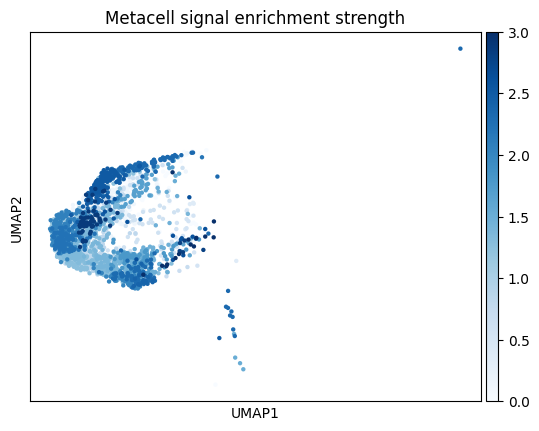

/mnt/research/FishEvoDevoGeno/Hao/software/anaconda3/envs/icepop/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


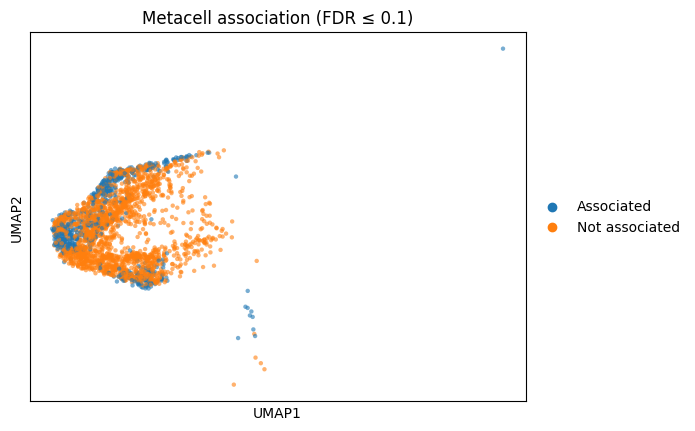

In [5]:
ct = 'enterocyte of epithelium of large intestine'

# subset cells
sub_adata = adata[adata.obs['cell_type'] == ct].copy()

# read in Disease/trait-metacell type association table
mc_df = pd.read_csv("../results/TM_icepop_mc-75/metacell__trait-PASS_UC_deLange2017.csv")
# remove the column axis name ("mc_df")
mc_df.columns.name = None
# remove the index name ("metacell")
mc_df.index.name = None
mc_df = mc_df.set_index('metacell')

# FDR correction
mc_fdr = pd.read_csv("../results/TM_icepop_mc-75/mcfdr__trait-PASS_UC_deLange2017.csv", index_col=0)

# map metacell to q for the selected trait (ct)
mc2q = mc_fdr.loc[ct].to_dict()

sub_adata.obs['mc_z'] = sub_adata.obs['metacell'].map(mc_df['z'])
sub_adata.obs['mc_q'] = sub_adata.obs['metacell'].map(mc2q).fillna(1.0)

# mask trait-associated metacells
sub_adata.obs['mc_discovery'] = np.where(
    sub_adata.obs['mc_q'] <= 0.1,
    'Associated',
    'Not associated'
)

# plot continuous metacell signal (z-score; enrichment strength)
sc.pl.umap(
    sub_adata,
    color='mc_z',
    cmap='Blues',
    size=40,
    vmin=0,
    vmax=3,
    title='Metacell signal enrichment strength' 
)

# plot associated/not-associated metacells (binary significance based on FDR threshold: q < 0.01)
sc.pl.umap(
    sub_adata,
    color='mc_discovery',
    size=40,
    alpha=0.6,
    title='Metacell association (FDR ≤ 0.1)' 
)

## 4. Example code to check influenced genes

In [6]:
f = np.load('../results/TM_icepop_mc-75/dfbs__trait-PASS_UC_deLange2017.npz', allow_pickle=True)
cg_dfbs = pd.DataFrame(f['dfbs'], index=f['celltypes'], columns=f['genes'])
cg_dfbs.head()

,148398,26155,339451,84069,84808,9636,375790,401934,54991,254173,...,440836,113730,644186,1375,1120,23542,410,85358,49,11158
B cell,-0.000932,0.000130,-0.000158,0.005850,0.000927,-0.000448,-0.002667,0.004725,-0.003798,-0.005486,...,-0.009934,-0.004166,-0.001694,-0.000070,-0.000946,0.002945,0.003958,-0.003000,0.000036,0.000854
Bergmann glial cell,-0.000212,-0.000120,-0.000035,0.002078,0.000425,-0.000145,-0.000760,0.002038,-0.001270,-0.001849,...,-0.003293,-0.001360,-0.000576,0.000052,0.000569,-0.001603,0.000225,-0.000971,0.000092,0.000279
Brush cell of epithelium proper of large intestine,-0.000105,-0.000067,-0.000023,0.000763,0.000118,-0.000070,0.000117,-0.000857,0.000844,0.007579,...,0.000936,-0.000666,0.000692,0.000025,0.000160,0.000496,0.000783,-0.000475,0.000044,-0.000047
"CD4-positive, alpha-beta T cell",-0.000776,0.000105,-0.000094,0.004766,0.000617,0.000200,-0.002264,0.004960,0.000861,-0.003465,...,-0.007831,-0.007995,-0.001544,0.000046,-0.000305,0.002421,0.003501,-0.002543,0.000147,0.000738
"CD8-positive, alpha-beta T cell",-0.000060,0.000266,-0.000093,0.004366,0.000424,0.000330,-0.002084,0.002359,-0.001145,-0.003080,...,-0.007795,-0.003258,-0.001418,0.000030,0.000367,0.001670,0.003621,-0.002305,0.000146,0.000683


In [7]:
cg_dfbs_long = cg_dfbs.reset_index().melt(
    id_vars='index',
    var_name='Entrez',
    value_name='Influence score'
)

cg_dfbs_long = cg_dfbs_long.rename(columns={'index': 'Cell type'})
cg_dfbs_long = cg_dfbs_long[cg_dfbs_long["Influence score"] != 0]

# assess assocaitions using influence score threshold calculated as
# 2/np.sqrt(n), n is number of genes included in the analysis
n = cg_dfbs.shape[1]
threshold = 2 / np.sqrt(n)

cg_dfbs_long["Associated"] = cg_dfbs_long["Influence score"] >= threshold

# add gene info
mg = mygene.MyGeneInfo()

gene_ids = cg_dfbs_long["Entrez"].astype(str).unique().tolist()

gene_info = mg.querymany(
    gene_ids,
    scopes="entrezgene",
    fields="symbol",
    species="human",
    as_dataframe=True
)

gene_map = gene_info[['symbol']]
gene_map.index.name = "Entrez"
gene_map = gene_map.reset_index()

cg_dfbs_long["Entrez"] = cg_dfbs_long["Entrez"].astype(str)
gene_map["Entrez"] = gene_map["Entrez"].astype(str)

cg_dfbs_final = cg_dfbs_long.merge(gene_map, on="Entrez", how="left")
cg_dfbs_final = cg_dfbs_final.rename(columns={"symbol": "Gene"})

# read in disease-cell association result
disease_cell_asso = pd.read_csv("../results/TM_icepop_mc-75/celltype__trait-PASS_UC_deLange2017.csv")
# merge FDR values to the cg_dfbs table
cg_dfbs_final = cg_dfbs_final.merge(
    disease_cell_asso[["cell_type", "q"]],
    left_on="Cell type",
    right_on="cell_type",
    how="left"
)

# finalize and add influence score rank
cg_dfbs_final = cg_dfbs_final.drop(columns=["cell_type"])
cg_dfbs_final = cg_dfbs_final.rename(columns={"q": "FDR"})
cg_dfbs_final = cg_dfbs_final.sort_values(by="Influence score", ascending=False)
cg_dfbs_final['Influence score rank'] = range(1, len(cg_dfbs_final) + 1)

cg_dfbs_final = cg_dfbs_final[
    [
        "Gene",
        "Entrez",
        "Cell type",
        "FDR",
        "Associated",
        "Influence score",
        "Influence score rank",
    ]
]

cg_dfbs_final[(cg_dfbs_final['FDR'] <= 0.1) & (cg_dfbs_final['Associated'])].head(10).head()

,Gene,Entrez,Cell type,FDR,Associated,Influence score,Influence score rank
679974,SLC26A3,1811,enterocyte of epithelium of large intestine,7.144742e-02,True,0.765625,12
73038,IL23R,149233,T cell,1.982394e-16,True,0.680524,17
431057,PF4,5196,monocyte,5.758207e-03,True,0.647159,19
832152,CARD9,64170,granulocyte monocyte progenitor cell,4.365916e-02,True,0.532770,25
281483,CXCR2,3579,granulocyte,3.643358e-04,True,0.529185,26
